In [1]:
from dataclasses import dataclass
import numpy as np
import os
import random
import pytesseract
import time
import torch
import torchvision.transforms as transforms

if not os.path.exists("./KuiSCIMA"):
    !git clone https://github.com/SuziAI/KuiSCIMA.git
if not os.path.exists("./gui-tools"):
    !git clone https://github.com/SuziAI/gui-tools.git

from data_extraction import *
from image_manipulation import *
from model import *
from lvlvpu import *

BATCH_SIZE = 100

In [2]:
# Extract data from KuiSCIMA dataset
extract_data()

# Set seeds
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

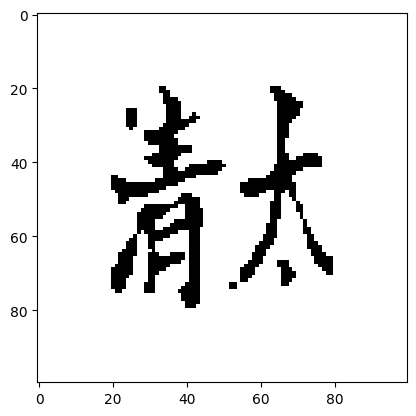

In [36]:
total_dataset = open_lvlvpu_dataset("./TotalDataset/Music/")
total_dataset = get_cropped_dataset(total_dataset, remove_blobs=False)

def add_whitespace(image, padding=20):
    """Adds whitespace around the image."""
    height, width = image.shape
    new_img = np.full((height + 2*padding, width + 2*padding), 255, dtype=np.uint8)  # White background
    new_img[padding:padding+height, padding:padding+width] = image  # Paste original
    return new_img

def preprocess_image(img):
    img = cv2.resize(img, (60, 60), interpolation=cv2.INTER_CUBIC)  # Upscale
    img = cv2.GaussianBlur(img, (3,3), 0)  # Reduce noise
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]  # Binarization
    img = add_whitespace(img)
    return img
    

plt.imshow(preprocess_image(total_dataset[48]["image"]).squeeze(), cmap="gray")

# Test with Tesseract OCR

In [10]:
from tqdm import tqdm
from PIL import Image

import pytesseract
def predict_lvlv_from_images(image_list, psm):
    char_whitelist = '''清黃大太夹姑仲蕤林夷南無應折字'''
    tesseract_config = f'''--psm {psm} -c tessedit_char_whitelist={char_whitelist} --tessdata-dir "../../gui-tools/weights"'''
    output = []

    for num, img in enumerate(image_list):
        img = np.asarray(img)
        try:
            img = 1-img.squeeze()
            new_p = Image.fromarray(img).convert('RGB')
            raw = pytesseract.image_to_string(new_p, lang="tessdata_chi_tra", config=tesseract_config)
        except pytesseract.pytesseract.TesseractError as error:
            print("\n\n Error: Need to install tesseract chi_tra. Refer to README.md to install.")
            print(error)
            return None

        if raw is None or raw == "\x0c" or len(raw) == 0:
            prediction = dataclasses.astuple(ExtendedLvlv()).index(ExtendedLvlv.NANLV)
        elif "折" in raw or "字" in raw:
            prediction = dataclasses.astuple(ExtendedLvlv()).index(ExtendedLvlv.ZHE_ZI)
        else:
            try:
                prediction = dataclasses.astuple(ExtendedLvlv()).index(ExtendedLvlv.from_name(raw.strip().replace(" ", "")))
            except KeyError:
                prediction = dataclasses.astuple(ExtendedLvlv()).index(ExtendedLvlv.NANLV)
        
        output.append(prediction)
    return output, raw

def test_tesseract(total_dataset, psm):  
    pred_y = []
    full_labels = []
        
    for idx, entry in enumerate(total_dataset):
        output, raw = predict_lvlv_from_images([preprocess_image(entry["image"])], psm=psm)
        pred_y += output
        full_labels.append(entry["annotation"])
        print(f"{idx+1}/{len(total_dataset)}: {float((torch.Tensor(full_labels) == torch.Tensor(pred_y)).sum()/len(full_labels))*100:.2f}% ({output[0]} {entry['annotation']}) {raw}")
    
    labels = torch.Tensor(full_labels)
    pred_y = torch.Tensor(pred_y)

    
    total_accuracy = (pred_y == labels).sum() / float(len(pred_y))

    print ('    Acc.(Total): {:.2f}%'.format(total_accuracy*100))
    
    return total_accuracy, pred_y, labels


start = time.time()
accuracy = test_tesseract(total_dataset, "6")
duration = time.time() - start
print("duration", duration)

1/3384: 100.00% (9 9) 南

2/3384: 50.00% (0 6) 黃   

3/3384: 66.67% (7 7) 林

4/3384: 75.00% (9 9) 南

5/3384: 80.00% (7 7) 林

6/3384: 83.33% (0 0) 黃

7/3384: 71.43% (9 2) 
8/3384: 75.00% (4 4) 姑

9/3384: 66.67% (0 6) 黃   

10/3384: 70.00% (4 4) 姑

11/3384: 63.64% (1 2) 大

12/3384: 66.67% (4 4) 姑

13/3384: 69.23% (7 7) 林

14/3384: 71.43% (12 12) 清黃

15/3384: 73.33% (14 14) 清太

16/3384: 68.75% (9 12)  黃     
 黃 

17/3384: 70.59% (11 11) 應

18/3384: 66.67% (8 9)  夷 

19/3384: 68.42% (7 7) 林

20/3384: 70.00% (9 9) 南

21/3384: 71.43% (0 0)   黃 

22/3384: 68.18% (1 2) 大

23/3384: 69.57% (0 0) 黃

24/3384: 70.83% (4 4) 姑

25/3384: 68.00% (8 6) 夷    

26/3384: 69.23% (4 4) 姑

27/3384: 66.67% (1 2) 大

28/3384: 67.86% (4 4) 姑

29/3384: 68.97% (7 7) 林

30/3384: 70.00% (0 0) 黃

31/3384: 70.97% (2 2) 太

32/3384: 71.88% (0 0) 黃

33/3384: 72.73% (9 9) 南

34/3384: 73.53% (12 12) 清黃

35/3384: 74.29% (11 11) 應

36/3384: 75.00% (9 9) 南

37/3384: 72.97% (8 6) 夷 

38/3384: 71.05% (9 7)   夷黃 

39/3384: 69.23% 

NameError: name 'all_accuracies' is not defined

In [11]:
start = time.time()
accuracy = test_tesseract(total_dataset, "8")
duration = time.time() - start
print("duration", duration)

1/3384: 100.00% (9 9) 南

2/3384: 50.00% (0 6) 黃   

3/3384: 66.67% (7 7) 林

4/3384: 75.00% (9 9) 
5/3384: 80.00% (7 7) 林

6/3384: 66.67% (12 0) 清 黃

7/3384: 57.14% (9 2) 
8/3384: 50.00% (9 4) 黃  黃

9/3384: 44.44% (0 6) 黃   

10/3384: 40.00% (9 4) 
11/3384: 36.36% (9 2) 
12/3384: 33.33% (9 4) 
13/3384: 38.46% (7 7) 林

14/3384: 42.86% (12 12) 清黃

15/3384: 46.67% (14 14) 清太

16/3384: 43.75% (9 12) 
17/3384: 47.06% (11 11) 應

18/3384: 44.44% (8 9)  夷 

19/3384: 47.37% (7 7) 林

20/3384: 50.00% (9 9) 
21/3384: 52.38% (0 0)   黃 

22/3384: 50.00% (1 2) 大

23/3384: 47.83% (9 0) 清  清  

24/3384: 50.00% (4 4) 姑

25/3384: 48.00% (9 6) 
26/3384: 46.15% (9 4) 黃 黃 黃

27/3384: 44.44% (1 2) 大

28/3384: 42.86% (9 4) 
29/3384: 44.83% (7 7) 林

30/3384: 46.67% (0 0)  黃

31/3384: 48.39% (2 2) 太

32/3384: 50.00% (0 0)   黃 

33/3384: 51.52% (9 9) 
34/3384: 52.94% (12 12) 清黃

35/3384: 54.29% (11 11) 應

36/3384: 55.56% (9 9) 南

37/3384: 54.05% (9 6) 
38/3384: 52.63% (9 7)   夷黃 

39/3384: 51.28% (8 6) 夷

40/3384

In [12]:
start = time.time()
accuracy = test_tesseract(total_dataset, "7")
duration = time.time() - start
print("duration", duration)

1/3384: 100.00% (9 9) 南

2/3384: 50.00% (0 6) 黃   

3/3384: 66.67% (7 7) 林

4/3384: 75.00% (9 9) 南

5/3384: 80.00% (7 7) 林

6/3384: 83.33% (0 0) 黃

7/3384: 71.43% (9 2) 
8/3384: 75.00% (4 4) 姑

9/3384: 66.67% (0 6) 黃   

10/3384: 60.00% (9 4) 
11/3384: 54.55% (1 2) 大

12/3384: 50.00% (9 4) 
13/3384: 53.85% (7 7) 林

14/3384: 57.14% (12 12) 清黃

15/3384: 60.00% (14 14) 清太

16/3384: 56.25% (9 12) 
17/3384: 58.82% (11 11) 應

18/3384: 55.56% (8 9)  夷 

19/3384: 57.89% (7 7) 林

20/3384: 60.00% (9 9) 
21/3384: 61.90% (0 0)   黃 

22/3384: 59.09% (1 2) 大

23/3384: 60.87% (0 0) 黃

24/3384: 62.50% (4 4) 姑

25/3384: 60.00% (9 6) 
26/3384: 61.54% (4 4) 姑

27/3384: 59.26% (1 2) 大

28/3384: 57.14% (9 4) 
29/3384: 58.62% (7 7) 林

30/3384: 60.00% (0 0) 黃

31/3384: 61.29% (2 2) 太

32/3384: 62.50% (0 0) 黃

33/3384: 63.64% (9 9) 
34/3384: 64.71% (12 12) 清黃

35/3384: 65.71% (11 11) 應

36/3384: 66.67% (9 9) 南

37/3384: 64.86% (9 6) 
38/3384: 63.16% (9 7)   夷黃 

39/3384: 61.54% (8 6) 夷

40/3384: 60.00% (9 4) 

In [19]:
shanghai = [entry for entry in total_dataset if entry["edition"] == "shanghai"]

timing_list = []
for idx in range(15):
    start = time.time()
    accuracy = test_tesseract(shanghai, "7")
    duration = time.time() - start
    timing_list.append(duration)

1/677: 100.00% (9 9) 南

2/677: 50.00% (9 6) 
3/677: 66.67% (7 7) 林

4/677: 75.00% (9 9) 南

5/677: 80.00% (7 7) 林

6/677: 83.33% (0 0)   黃 

7/677: 71.43% (1 2) 大

8/677: 75.00% (4 4)  姑  

9/677: 66.67% (9 6) 
10/677: 70.00% (4 4) 姑

11/677: 63.64% (1 2) 大

12/677: 66.67% (4 4) 姑

13/677: 69.23% (7 7) 林

14/677: 71.43% (12 12) 清黃

15/677: 73.33% (14 14) 清太

16/677: 68.75% (9 12)   無黃 黃

17/677: 64.71% (0 11) 黃   

18/677: 66.67% (9 9) 南

19/677: 68.42% (7 7) 林

20/677: 70.00% (9 9) 南

21/677: 66.67% (8 0)   夷

22/677: 63.64% (1 2) 大

23/677: 60.87% (1 0) 大

24/677: 58.33% (9 4) 
25/677: 56.00% (9 6) 
26/677: 53.85% (0 4)     黃

27/677: 51.85% (1 2) 大

28/677: 53.57% (4 4) 姑

29/677: 51.72% (8 7) 夷

30/677: 50.00% (8 0) 夷

31/677: 48.39% (1 2) 大

32/677: 50.00% (0 0) 黃

33/677: 48.48% (4 9) 姑  

34/677: 50.00% (12 12) 清黃

35/677: 51.43% (11 11) 應

36/677: 52.78% (9 9) 南

37/677: 51.35% (9 6) 
38/677: 52.63% (7 7) 林

39/677: 51.28% (9 6) 
40/677: 52.50% (4 4) 姑

41/677: 53.66% (0 0) 黃

4

In [37]:
timing_list = np.array(timing_list)
print(f"{timing_list.mean()/60:.2f} +- {timing_list.std()/50:.2f} minutes")

7.87 +- 0.08 minutes
